# Principal Component Analysis of the SymbTr v3.0 Corpus

Principal Component Analysis (PCA) is one of the most widely used dimensionality reduction techniques in statistics and machine learning. It transforms a set of potentially correlated variables into a smaller number of uncorrelated variables, called **principal components**, while preserving as much of the original data variability as possible.

For symbolic music corpora, PCA provides an effective way to summarize high-dimensional musical representations and to identify the dominant patterns underlying the dataset. Rather than analyzing each symbolic attribute independently, PCA reveals how multiple variables jointly contribute to the overall structure of the corpus.

In this chapter, PCA is applied to the numerical attributes extracted from the SymbTr corpus. The analysis investigates the proportion of variance explained by each principal component, visualizes the distribution of musical notation elements in the reduced feature space, and examines the contribution of individual variables to the resulting components. These analyses provide valuable insight into the intrinsic structure of the symbolic music representation and establish a foundation for the clustering analyses presented in the following chapter.

## Loading the Processed SymbTr Corpus

The processed SymbTr corpus is loaded from the standardized CSV file generated during the preprocessing stage. Using a processed dataset ensures that all subsequent analyses are performed on a consistent version of the corpus without repeatedly parsing the original symbolic music files. This approach improves computational efficiency, enhances reproducibility, and allows each notebook in this book to be executed independently.

After loading the dataset, the notebook reports its dimensions and displays a concise preview to verify that the corpus has been imported successfully and is ready for analysis.

The processed corpus contains **1,211,922 symbolic events** extracted from **3,000 musical pieces**. Each symbolic event is described by the **14 original SymbTr variables** together with an additional **Piece ID** variable introduced during preprocessing. The **Piece ID** uniquely identifies the musical piece from which each symbolic event originates, enabling event-level analyses while preserving the relationship between symbolic notation elements and their corresponding musical pieces. Collectively, these variables capture complementary aspects of Turkish makam music, including symbolic pitch, microtonal accidentals, rhythmic duration, structural attributes, lyrics, positional information, and musical piece identifiers.

In [14]:
from pathlib import Path
import pandas as pd

# Define the project directories
project_root = Path.cwd().parent

data_directory = project_root / "data"
processed_data_directory = data_directory / "processed"

# Define and load the processed corpus file
corpus_file = processed_data_directory / "symbtr_corpus.csv"
corpus_df = pd.read_csv(corpus_file)

# Display a concise corpus summary
print("=" * 60)
print("             SymbTr Corpus Successfully Loaded")
print("=" * 60)
print(f"Dataset shape   : {corpus_df.shape}")
print(f"Records         : {len(corpus_df):,}")
print(f"Variables       : {corpus_df.shape[1]}")
print("Source          : processed data directory")
print("=" * 60)

# Create a compact preview by excluding the long Piece ID column
preview_df = (
    corpus_df
    .drop(columns=["Piece ID"], errors="ignore")
    .head()
)

display(
    preview_df.style.hide(axis="index")
)

             SymbTr Corpus Successfully Loaded
Dataset shape   : (1211994, 15)
Records         : 1,211,994
Variables       : 15
Source          : processed data directory


Sira,Kod,Nota53,NotaAE,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Soz1,Offset,Source File
1,9,Do5,C5,318,318,1,4,714,95,96,Al,0.250000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
2,9,Fa5,F5,340,340,3,16,536,99,96,dan,0.437500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
3,9,Mi5,E5,336,336,1,16,179,95,96,nan,0.500000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
4,9,Sol5,G5,349,349,1,16,179,99,96,ma,0.562500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
5,9,Fa5,F5,340,340,1,16,179,99,96,nan,0.625000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt


## Selecting Numerical Variables

Many statistical analyses and visualization techniques require numerical input variables. In this step, the numerical variables of the SymbTr corpus are selected to create a dedicated dataset for subsequent statistical analysis, dimensionality reduction, and machine learning tasks.

The selected variables describe symbolic musical properties, including microtonal pitch values, rhythmic information, score position, and temporal location. Creating a separate numerical dataset simplifies subsequent analyses while preserving the original corpus unchanged.

**Output.** This cell extracts the numerical variables, reports the dimensions of the resulting dataset, and displays a preview of the selected features.

In [15]:
numerical_columns = [
    "Sira",
    "Kod",
    "Koma53",
    "KomaAE",
    "Pay",
    "Payda",
    "Ms",
    "LNS",
    "Bas",
    "Offset",
]

X = corpus_df[numerical_columns].copy()

print(f"Number of variables: {X.shape[1]}")
print(f"Number of notation elements: {X.shape[0]}")

# Display with row numbers starting from 1
X_display = X.head().copy()
X_display.index = range(1, len(X_display) + 1)

display(X_display)

Number of variables: 10
Number of notation elements: 1211994


,Sira,Kod,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Offset
1,1,9,318,318,1,4,714,95,96,0.2500
2,2,9,340,340,3,16,536,99,96,0.4375
3,3,9,336,336,1,16,179,95,96,0.5000
4,4,9,349,349,1,16,179,99,96,0.5625
5,5,9,340,340,1,16,179,99,96,0.6250


### Interpretation

The numerical subset contains **1,211,922 symbolic notation elements** represented by **10 numerical variables**. These variables encode quantitative musical information, including pitch, rhythmic duration, score position, and temporal offsets. Constructing this numerical dataset provides a standardized input for the statistical visualizations, dimensionality reduction methods, and machine learning techniques presented in the subsequent chapters.

## Computing the Principal Components

After standardizing the numerical variables, Principal Component Analysis (PCA) can be applied to identify the dominant directions of variation within the SymbTr corpus.

Initially, PCA is computed using all available numerical variables. This approach allows the explained variance of every principal component to be examined before selecting an appropriate reduced-dimensional representation.

In [16]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select the numerical variables used in the PCA analysis
numerical_columns = [
    "Sira",
    "Kod",
    "Koma53",
    "KomaAE",
    "Pay",
    "Payda",
    "Ms",
    "LNS",
    "Bas",
    "Offset",
]

# Verify that all required columns exist
missing_columns = [
    column for column in numerical_columns
    if column not in corpus_df.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are missing from the corpus: "
        + ", ".join(missing_columns)
    )

# Create the numerical analysis dataframe
X = corpus_df[numerical_columns].copy()

# Convert all selected variables to numerical values
# Invalid or non-numerical values are converted to NaN
X = X.apply(pd.to_numeric, errors="coerce")

# Replace positive and negative infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Report missing values before cleaning
missing_value_counts = X.isna().sum()
total_missing_values = int(missing_value_counts.sum())

print("=" * 60)
print("             PCA Data Preparation Summary")
print("=" * 60)
print(f"Initial notation elements : {len(X):,}")
print(f"Selected variables        : {X.shape[1]}")
print(f"Missing values detected   : {total_missing_values:,}")
print("=" * 60)

# Remove rows containing missing or invalid values
X_clean = X.dropna().copy()

if X_clean.empty:
    raise ValueError(
        "No valid observations remain after removing missing values."
    )

# Standardize the numerical variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Compute the principal components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print()
print("=" * 60)
print("        Principal Components Successfully Computed")
print("=" * 60)
print(f"Notation elements used : {X_pca.shape[0]:,}")
print(f"Rows removed           : {len(X) - len(X_clean):,}")
print(f"Principal components   : {X_pca.shape[1]}")
print("=" * 60)

# Create a dataframe containing the principal component scores
principal_component_columns = [
    f"PC{i}"
    for i in range(1, X_pca.shape[1] + 1)
]

pca_scores_df = pd.DataFrame(
    X_pca,
    columns=principal_component_columns,
    index=X_clean.index,
)

# Display the first five PCA scores with row numbers starting from 1
pca_preview = pca_scores_df.head().copy()
pca_preview.index = range(1, len(pca_preview) + 1)

display(
    pca_preview.style.format(precision=4)
)

             PCA Data Preparation Summary
Initial notation elements : 1,211,994
Selected variables        : 10
Missing values detected   : 0

        Principal Components Successfully Computed
Notation elements used : 1,211,994
Rows removed           : 0
Principal components   : 10


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1,0.0526,0.1253,-1.6032,-1.0912,0.0302,0.2838,0.2520,-0.0120,0.1287,-0.0004
2,0.5970,-0.1220,-1.9776,2.5050,0.8514,-0.2055,-0.1659,-0.8709,-0.1305,-0.0005
3,0.6650,-1.6234,-0.4516,0.1497,-0.1555,-0.2172,0.0622,0.0266,-0.0842,-0.0006
4,0.7649,-1.6883,-0.3449,0.2847,0.5566,0.3205,0.0269,-0.0034,-0.2451,-0.0005
5,0.6137,-1.6972,-0.3393,0.2889,0.5517,0.2885,0.0278,0.0009,-0.1371,-0.0006


### Interpretation

The numerical variables were successfully standardized using the **StandardScaler** algorithm before applying Principal Component Analysis (PCA). Standardization ensures that all variables contribute equally to the analysis by transforming them to a common scale with zero mean and unit variance.

PCA was then applied to the standardized dataset, producing **10 principal components**, corresponding to the **10 numerical variables** included in the analysis. The table above presents the first five symbolic notation elements represented in the new principal component space. Each principal component is a linear combination of the original variables and captures a different source of variation within the dataset.

These principal component scores provide a compact representation of the original numerical variables and serve as the basis for the variance analysis, visualization, and clustering techniques presented in the following sections.


## Explained Variance of the Principal Components

Each principal component explains a proportion of the total variance contained in the standardized numerical dataset. Components with larger explained variance preserve more information from the original variables and therefore contribute more strongly to representing the underlying structure of the symbolic music corpus.

The explained variance ratio and cumulative explained variance are computed for every principal component. These measures provide a quantitative basis for determining the number of principal components that should be retained for subsequent dimensionality reduction, visualization, and clustering analyses.

**Output.** This cell reports the explained variance ratio and cumulative explained variance associated with each principal component.

In [17]:
import numpy as np
import pandas as pd

# Create a summary table of the explained variance
explained_variance = pd.DataFrame(
    {
        "Principal Component": [
            f"PC{i + 1}"
            for i in range(len(pca.explained_variance_ratio_))
        ],
        "Explained Variance Ratio": pca.explained_variance_ratio_,
        "Explained Variance (%)": pca.explained_variance_ratio_ * 100,
        "Cumulative Variance (%)": (
            np.cumsum(pca.explained_variance_ratio_) * 100
        ),
    }
)

# Apply display precision
explained_variance["Explained Variance Ratio"] = (
    explained_variance["Explained Variance Ratio"].round(4)
)

explained_variance["Explained Variance (%)"] = (
    explained_variance["Explained Variance (%)"].round(2)
)

explained_variance["Cumulative Variance (%)"] = (
    explained_variance["Cumulative Variance (%)"].round(2)
)

print("=" * 60)
print("        Explained Variance Successfully Computed")
print("=" * 60)
print(f"Principal components : {len(explained_variance)}")

print("=" * 60)

explained_variance.style.hide(axis="index")

        Explained Variance Successfully Computed
Principal components : 10


Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
PC1,0.302700,30.270000,30.270000
PC2,0.166200,16.620000,46.890000
PC3,0.151300,15.130000,62.030000
PC4,0.112000,11.200000,73.230000
PC5,0.095100,9.510000,82.740000
PC6,0.093400,9.340000,92.080000
PC7,0.044300,4.430000,96.520000
PC8,0.025700,2.570000,99.080000
PC9,0.009200,0.920000,100.000000
PC10,0.000000,0.000000,100.000000


### Interpretation

The explained variance analysis shows that the first principal components capture a substantial proportion of the variability present in the standardized symbolic music dataset. The first principal component (**PC1**) explains **30.27%** of the total variance, while the first three principal components together account for **62.03%** of the overall variability.

The cumulative explained variance reaches **92.08%** after the first six principal components and **99.08%** after the first eight principal components. These results indicate that much of the variability contained in the original ten numerical variables can be represented using a reduced number of dimensions.

Overall, the results suggest that Principal Component Analysis provides an effective low-dimensional representation of the numerical features in the SymbTr corpus. The leading principal components retain a large proportion of the dataset's variance and therefore provide a suitable basis for the visualization and clustering analyses presented in the following sections.

### Key Observations

- The first principal component explains **30.27%** of the total variance.
- The first three principal components preserve **62.03%** of the dataset variability.
- The first six principal components retain **92.08%** of the total variance.
- More than **99%** of the dataset variability is preserved by the first eight principal components.
- The results indicate that the symbolic music corpus can be represented effectively using a lower-dimensional feature space.

## Scree Plot

The scree plot visualizes the proportion of variance explained by each principal component. Components appearing before the curve begins to flatten generally capture the most significant variation in the dataset, whereas later components contribute progressively less additional information.

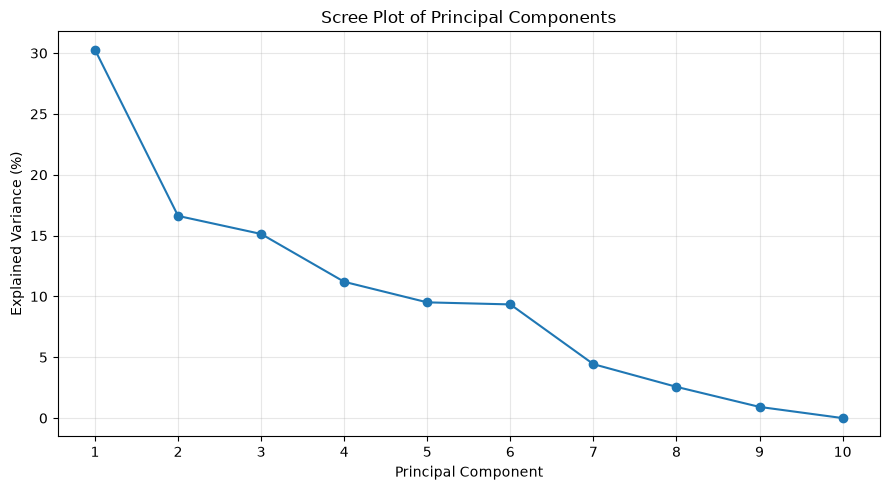

In [18]:
import matplotlib.pyplot as plt

# Create the scree plot
principal_components = range(
    1,
    len(pca.explained_variance_ratio_) + 1,
)

explained_variance_percent = (
    pca.explained_variance_ratio_ * 100
)

plt.figure(figsize=(9, 5))

plt.plot(
    principal_components,
    explained_variance_percent,
    marker="o",
)

plt.xticks(principal_components)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot of Principal Components")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The scree plot illustrates the proportion of variance explained by each principal component. The first principal component (**PC1**) accounts for approximately **30%** of the total variance, while the explained variance decreases progressively across the subsequent components.

A pronounced decline is observed between the first few principal components, followed by a more gradual decrease in explained variance. After approximately the **sixth principal component**, each additional component contributes only a relatively small proportion of the remaining variance.

This pattern indicates that a relatively small number of principal components captures a substantial proportion of the variability present in the original ten numerical variables. In particular, the first **six to eight principal components** account for most of the total variance and therefore provide a compact low-dimensional representation suitable for the subsequent visualization and clustering analyses.

The scree plot shows that the first principal components capture the majority of the variability present in the standardized symbolic music corpus. The first principal component (PC1) explains approximately **30%** of the total variance, indicating that a substantial proportion of the information contained in the original numerical variables is concentrated along a single direction.

The explained variance decreases rapidly across the first several principal components, after which the curve gradually levels off. An elbow is observed after approximately the **sixth principal component**, suggesting that subsequent components contribute only limited additional information.

This pattern indicates that the original ten numerical variables can be represented effectively using a considerably smaller number of principal components. Consequently, retaining approximately **six to eight principal components** provides a compact low-dimensional representation of the SymbTr corpus while preserving nearly all of the variability contained in the original dataset.

### Key Observations

- The first principal component (**PC1**) explains approximately **30%** of the total variance.
- The explained variance decreases substantially across the first several principal components before gradually leveling off.
- The first **six** principal components together account for more than **92%** of the total variance.
- The first **eight** principal components together account for more than **99%** of the total variance.
- Only a small proportion of the total variance is explained by the remaining principal components.
- These results indicate that the original ten numerical variables can be represented using a reduced number of principal components while retaining most of the variability in the dataset.

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numerical_columns,
)

loadings = loadings.round(3)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Sira,-0.006,0.402,0.569,0.146,-0.026,-0.018,0.692,-0.113,0.009,0.000
Kod,-0.160,-0.039,-0.055,0.275,-0.584,0.733,0.025,0.112,-0.049,0.000
Koma53,0.565,0.041,-0.011,-0.014,0.017,0.120,-0.001,-0.016,-0.404,-0.707
KomaAE,0.565,0.041,-0.011,-0.014,0.017,0.120,-0.001,-0.016,-0.404,0.707
Pay,0.011,0.309,-0.358,0.703,0.042,-0.159,-0.117,-0.491,0.008,0.000
Payda,0.116,-0.440,0.205,0.616,0.027,-0.277,0.040,0.540,-0.011,-0.000
Ms,-0.049,0.562,-0.463,-0.012,0.155,0.009,0.168,0.643,-0.016,0.000
LNS,-0.133,-0.093,0.121,0.157,0.792,0.552,-0.040,-0.027,-0.005,0.000
Bas,0.548,0.040,-0.018,0.005,-0.010,0.163,-0.009,0.018,0.819,-0.000
Offset,-0.019,0.466,0.522,0.061,-0.061,-0.014,-0.690,0.163,-0.008,0.000


### Interpretation

The loading matrix shows the contribution of each original numerical variable to the extracted principal components. Variables with larger absolute loading values have a stronger influence on the corresponding principal component and therefore contribute more substantially to the observed variability captured by that component.

The first principal component (**PC1**) is primarily influenced by **Koma53** (0.565), **KomaAE** (0.565), and **Bas** (0.548). The second principal component (**PC2**) receives its largest contributions from **Ms** (0.562), **Offset** (0.466), and **Payda** (-0.440). The third principal component (**PC3**) is mainly associated with **Sira** (0.569), **Offset** (0.522), and **Ms** (-0.463).

Subsequent principal components are dominated by different subsets of variables. For example, **PC4** is strongly influenced by **Pay** (0.703) and **Payda** (0.616), **PC5** by **LNS** (0.792) and **Kod** (-0.584), and **PC6** by **Kod** (0.733) together with **LNS** (0.552).

Overall, the loading matrix indicates that different principal components are influenced by different combinations of the original numerical variables. This distribution of loadings suggests that the variability in the SymbTr corpus is distributed across multiple complementary dimensions rather than being dominated by a single variable.

### Key Observations

- **PC1** is primarily influenced by **Koma53**, **KomaAE**, and **Bas**, which exhibit the largest absolute loading values for this component.
- **PC2** is mainly associated with **Ms**, **Offset**, and **Payda**, indicating that these variables contribute most strongly to the second principal component.
- **PC3** receives its largest contributions from **Sira**, **Offset**, and **Ms**.
- **PC4** is dominated by **Pay** and **Payda**, which have the highest loading values for this component.
- **PC5** and **PC6** are strongly influenced by **LNS** and **Kod**, respectively, together with contributions from additional variables.
- The loading matrix shows that different principal components are characterized by different combinations of the original numerical variables, indicating that the variability of the SymbTr corpus is distributed across multiple complementary dimensions.

# PCA Projection

Although the original SymbTr corpus is represented by ten numerical variables, the principal components provide a lower-dimensional representation of the data while preserving most of its variability.

The following visualization projects every symbolic notation element onto the space defined by the first two principal components (**PC1** and **PC2**). Since these two components explain nearly half of the total variance, they provide an informative overview of the global distribution of the symbolic music corpus.

Each point in the scatter plot corresponds to one symbolic notation element. The relative distances between points reflect their similarity in the reduced principal component space. Clusters, dense regions, or isolated observations may indicate common symbolic structures or distinctive notation patterns within the corpus.

In [20]:
pca_projection = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
    }
)

print("=" * 60)
print("        Two-Dimensional PCA Projection Created")
print("=" * 60)
print(f"Notation elements : {len(pca_projection):,}")
print(f"Principal components : {pca_projection.shape[1]}")
print("=" * 60)

(
    pca_projection
    .head()
    .round(3)
    .style
    .hide(axis="index")
    .format("{:.3f}")
)

        Two-Dimensional PCA Projection Created
Notation elements : 1,211,994
Principal components : 2


PC1,PC2
0.053,0.125
0.597,-0.122
0.665,-1.623
0.765,-1.688
0.614,-1.697


### Interpretation

The PCA projection represents each symbolic notation element using the first two principal components (**PC1** and **PC2**). Instead of being described by the original ten standardized numerical variables, each notation element is represented by two coordinates corresponding to its position in the reduced principal component space.

The values shown in the table are the principal component scores obtained after applying PCA. Notation elements with similar coordinates are located closer to one another in the two-dimensional projection, whereas elements with substantially different coordinates are positioned farther apart according to the variability captured by the first two principal components.

Together, **PC1** and **PC2** account for **46.89%** of the total variance in the numerical dataset. Although this projection does not capture all of the variability present in the original data, it provides a concise two-dimensional representation that is useful for visualizing the overall distribution of symbolic notation elements and forms the basis for the scatter plot and clustering analyses presented in the following sections.

### Key Observations

- Each symbolic notation element is represented by a pair of coordinates defined by **PC1** and **PC2**.
- The projection reduces the original ten-dimensional feature space to two dimensions while preserving the dominant patterns of variation.
- Nearby points in the projected space are expected to represent notation elements with similar symbolic characteristics.
- The two-dimensional projection provides the basis for visual exploration and clustering of the symbolic music corpus.

## Visualizing the PCA Projection

Although the original SymbTr corpus is represented by ten standardized numerical variables, the first two principal components provide a compact two-dimensional representation that preserves a substantial proportion of the overall variability.

This visualization projects every symbolic notation element onto the plane defined by the first two principal components (PC1 and PC2). Each point corresponds to a single notation element, while the relative distances between points reflect similarities in their underlying numerical characteristics after dimensionality reduction.

The resulting scatter plot provides an overview of the global structure of the symbolic music corpus and serves as the basis for identifying clusters, dense regions, and potential outliers in the reduced feature space.

**Output.** This cell displays the two-dimensional PCA projection of the symbolic music corpus using the first two principal components.

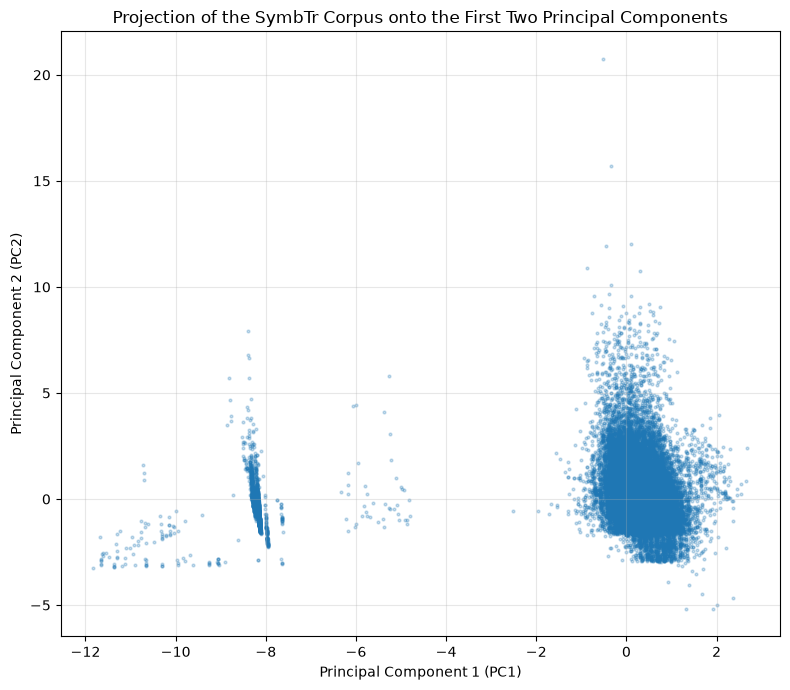

In [21]:
import matplotlib.pyplot as plt

# Randomly sample notation elements for visualization
sample = pca_projection.sample(
    n=50000,
    random_state=42,
)

plt.figure(figsize=(8, 7))

plt.scatter(
    sample["PC1"],
    sample["PC2"],
    s=4,
    alpha=0.25,
)

plt.title("Projection of the SymbTr Corpus onto the First Two Principal Components")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The PCA scatter plot shows that the symbolic notation elements are distributed unevenly within the two-dimensional principal component space. A large concentration of observations is located near the center of the projection, while several smaller groups and isolated observations appear in other regions of the plot.

The highest density of notation elements is observed around the central region, indicating that many observations occupy similar positions in the reduced feature space. In contrast, a distinct group is visible around **PC1 ≈ −8**, and additional sparse observations extend toward more negative PC1 values. A small number of observations are also separated from the main distribution along the positive direction of **PC2**.

Overall, the projection suggests that the numerical variables do not form a single uniform distribution in the reduced feature space. Instead, the observations exhibit regions of varying density together with several separated groups and isolated points. These distributional patterns indicate that further investigation using clustering techniques may help identify groups of notation elements with similar numerical characteristics.

### Key Observations

- A dominant high-density cluster occupies the central region of the PCA projection.
- A clearly separated secondary cluster is observed around **PC1 ≈ −8**.
- Several sparse groups and isolated observations appear at lower PC1 values.
- A small number of outliers are present, particularly at high positive values of **PC2**.
- The projection suggests that the symbolic music corpus contains multiple latent structural patterns, motivating the clustering analyses presented in the following sections.

# Variable Contributions to the Principal Components

While the loading matrix provides the numerical contribution of each variable to the principal components, a graphical representation makes these relationships easier to interpret.

The following heatmap visualizes the contribution of each original numerical variable to every principal component. Darker colors indicate stronger contributions, whereas lighter colors correspond to weaker relationships.

This visualization allows the dominant variables associated with each principal component to be identified quickly and provides an intuitive overview of the latent structure discovered by the PCA.

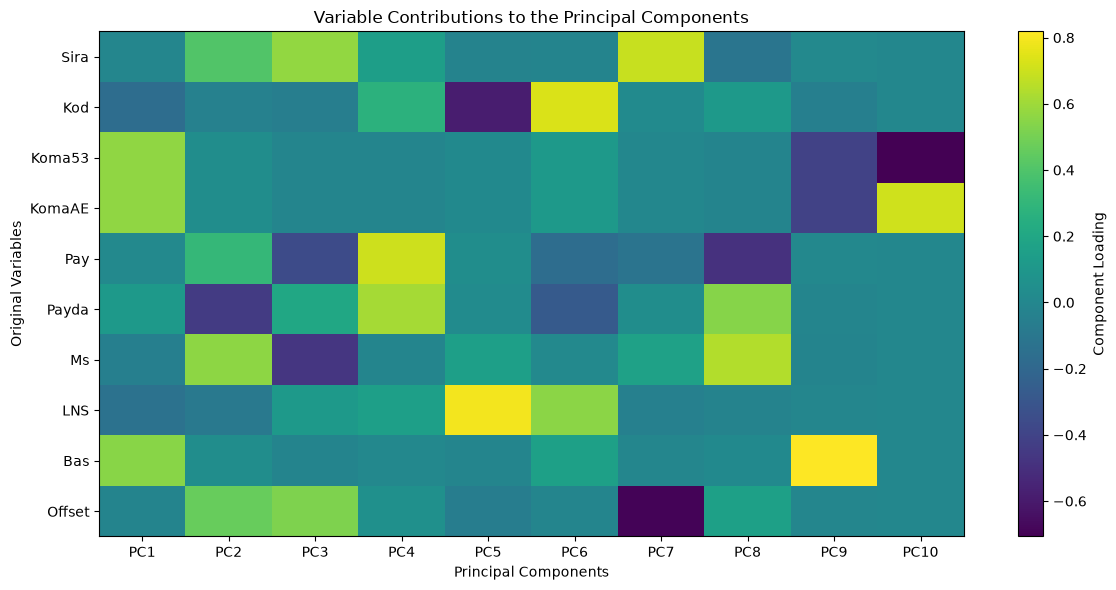

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

image = plt.imshow(
    loadings,
    aspect="auto",
    interpolation="nearest",
)

plt.colorbar(
    image,
    label="Component Loading",
)

plt.xticks(
    range(loadings.shape[1]),
    loadings.columns,
)

plt.yticks(
    range(loadings.shape[0]),
    loadings.index,
)

plt.xlabel("Principal Components")
plt.ylabel("Original Variables")
plt.title("Variable Contributions to the Principal Components")

plt.tight_layout()
plt.show()

### Interpretation

The heatmap provides a visual representation of the loading matrix, illustrating the contribution of each original numerical variable to the extracted principal components. Both the magnitude and the sign of the loading values indicate the relative influence of each variable on the corresponding principal component.

The first principal component (**PC1**) is primarily influenced by **Koma53**, **KomaAE**, and **Bas**. The second principal component (**PC2**) receives its strongest contributions from **Ms**, **Offset**, and **Payda**, while the third principal component (**PC3**) is mainly associated with **Sira**, **Offset**, and **Ms**.

Subsequent principal components are characterized by different combinations of variables. For example, **PC4** is strongly influenced by **Pay** and **Payda**, **PC5** by **LNS**, and **PC6** by **Kod** together with **LNS**. These patterns are consistent with the loading values presented in the previous table.

Overall, the heatmap illustrates that different principal components are influenced by different subsets of the original numerical variables. This distribution of loading values indicates that the variability captured by the principal components is distributed across multiple complementary combinations of variables rather than being dominated by a single variable.

### Key Observations

- **PC1** is primarily influenced by **Koma53**, **KomaAE**, and **Bas**.
- **PC2** receives its strongest contributions from **Ms**, **Offset**, and **Payda**.
- **PC3** is mainly associated with **Sira**, **Offset**, and **Ms**.
- **PC4** is dominated by **Pay** and **Payda**.
- **PC5** and **PC6** are strongly influenced by **LNS** and **Kod**, respectively.
- The heatmap shows that different principal components are characterized by different combinations of the original numerical variables, indicating that the variability in the dataset is distributed across multiple complementary dimensions.

## Saving the PCA Results

The PCA outputs generated in this chapter are saved to the **processed** data directory for reuse in subsequent analyses. Storing these intermediate datasets avoids repeating the computationally intensive dimensionality reduction process and ensures that all later analyses are based on the same PCA representation.

The saved files include the PCA feature space, the loading matrix, and the explained variance statistics. Before proceeding, the notebook verifies that each file has been successfully created.

**Output.** This cell saves the PCA results and confirms that all output files were successfully written to disk. The saved PCA feature space will be used as the input dataset for the clustering analyses presented in **Chapter 6**.

In [23]:
import pandas as pd

# Create the processed data directory if it does not exist
processed_data_directory.mkdir(parents=True, exist_ok=True)

# Output file paths
x_pca_path = processed_data_directory / "X_pca.csv"
loadings_path = processed_data_directory / "pca_loadings.csv"
variance_path = processed_data_directory / "explained_variance.csv"

# Directory name displayed without the full system path
display_directory = "data/processed/"

print("=" * 60)
print("                 Saving PCA Results")
print("=" * 60)
print(f"Output directory : {display_directory}")
print("=" * 60)

# ------------------------------------------------------------------
# Save PCA projection
# ------------------------------------------------------------------
print(f"Saving {x_pca_path.name}...")

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[
        f"PC{i}"
        for i in range(1, X_pca.shape[1] + 1)
    ],
)

X_pca_df.to_csv(
    x_pca_path,
    index=False,
)

print(f"✓ {x_pca_path.name} saved")

# ------------------------------------------------------------------
# Save PCA loading matrix
# ------------------------------------------------------------------
print(f"Saving {loadings_path.name}...")

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=numerical_columns,
    columns=[
        f"PC{i}"
        for i in range(1, pca.n_components_ + 1)
    ],
)

pca_loadings.index.name = "Variable"

pca_loadings.to_csv(
    loadings_path,
    index=True,
)

print(f"✓ {loadings_path.name} saved")

# ------------------------------------------------------------------
# Save explained variance table
# ------------------------------------------------------------------
print(f"Saving {variance_path.name}...")

explained_variance.to_csv(
    variance_path,
    index=False,
)

print(f"✓ {variance_path.name} saved")


# ------------------------------------------------------------------
# Human-readable file size
# ------------------------------------------------------------------
def human_readable_size(file_path):
    """Return the file size in a readable format."""

    size = file_path.stat().st_size

    if size < 1024:
        return f"{size} B"

    if size < 1024**2:
        return f"{size / 1024:.2f} KB"

    if size < 1024**3:
        return f"{size / (1024**2):.2f} MB"

    return f"{size / (1024**3):.2f} GB"


# ------------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------------
print()
print("=" * 60)
print("              Verifying Saved Files")
print("=" * 60)
print(f"Location : {display_directory}")
print("-" * 60)

output_files = [
    x_pca_path,
    loadings_path,
    variance_path,
]

for file_path in output_files:
    if file_path.exists():
        print(
            f"✓ {file_path.name:<28}"
            f"{human_readable_size(file_path):>12}"
        )
    else:
        print(
            f"✗ {file_path.name:<28}"
            f"{'Not found':>12}"
        )

print("=" * 60)
print("             PCA Results Successfully Saved")
print("=" * 60)

                 Saving PCA Results
Output directory : data/processed/
Saving X_pca.csv...
✓ X_pca.csv saved
Saving pca_loadings.csv...
✓ pca_loadings.csv saved
Saving explained_variance.csv...
✓ explained_variance.csv saved

              Verifying Saved Files
Location : data/processed/
------------------------------------------------------------
✓ X_pca.csv                      234.61 MB
✓ pca_loadings.csv                 2.12 KB
✓ explained_variance.csv             322 B
             PCA Results Successfully Saved


### Key Observations

- The PCA projection was successfully saved as **X_pca.csv**.
- The loading matrix was saved as **pca_loadings.csv**.
- The explained variance statistics were saved as **explained_variance.csv**.
- These intermediate files improve reproducibility and prevent unnecessary recomputation.
- The saved PCA feature space will serve as the input for the clustering analyses in **Chapter 6**.

## Next Chapter

Having examined the dimensional structure of the SymbTr corpus through Principal Component Analysis (PCA), the next chapter, **Clustering Analysis**, investigates the grouping of symbolic music representations using unsupervised clustering techniques.

The chapter identifies natural clusters within the reduced feature space and provides further insight into the internal organization of the SymbTr corpus.